
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [ ]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_
For dynamic querying (filters), `store_id`, `region`, `product`, `category`, `unit_price`, `units_sold`, and `month` would be excellent choices, as managers often want to narrow down data based on these attributes. For linking views (brushing), `store_id`, `product`, and `month` are ideal, as they allow for comparing specific entities or time periods across different visualizations.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


/tmp/ipykernel_3927/2391099836.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue', y='product', data=revenue_by_product, palette='viridis')


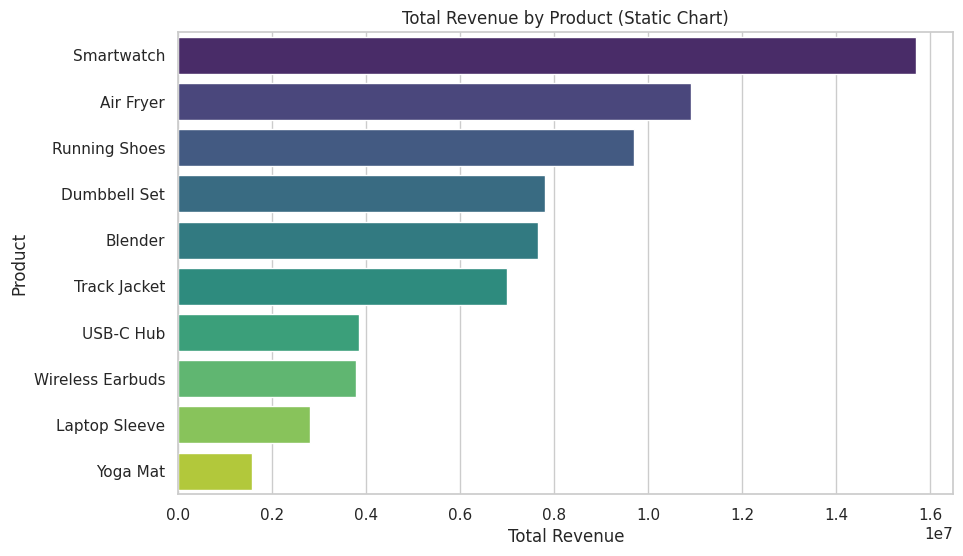

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1a. STATIC chart ---
# TODO:
#   - Group sales_df by "product", sum "revenue"
#   - Sort descending
#   - Plot a horizontal or vertical bar chart with matplotlib/seaborn
#   - Title it clearly

revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product', data=revenue_by_product, palette='viridis')
plt.title('Total Revenue by Product (Static Chart)')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.show()

In [ ]:

# --- 1b. INTERACTIVE chart ---
# TODO:
#   - Use plotly.express.bar on the SAME grouped data
#   - Add a hover field for "category" (hint: you'll need category alongside revenue -- think about
#     what columns your groupby needs to keep)
#   - Title it clearly

# TODO: plotting code here



In [ ]:
revenue_by_product_with_category = sales_df.groupby(["product", "category"])["revenue"].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    revenue_by_product_with_category,
    x='revenue',
    y='product',
    color='category', # Use category for color, which also adds it to hover info by default
    title='Total Revenue by Product (Interactive Chart)',
    hover_data={'category': True, 'revenue': ':,.2f'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

**Your 1-2 sentence answer:**
For this specific manager request, the interactive Plotly chart clearly wins. Its hover functionality directly addresses the need for precise revenue figures without needing to 'squint at a printed axis', offering a much better user experience for data exploration and precise value retrieval compared to a static chart.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [ ]:
price_slider = widgets.FloatRangeSlider(
    value=[sales_df['unit_price'].min(), sales_df['unit_price'].max()],
    min=sales_df['unit_price'].min(),
    max=sales_df['unit_price'].max(),
    step=1.0,
    description='Unit Price:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

units_slider = widgets.IntRangeSlider(
    value=[sales_df['units_sold'].min(), sales_df['units_sold'].max()],
    min=sales_df['units_sold'].min(),
    max=sales_df['units_sold'].max(),
    step=1,
    description='Units Sold:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def dynamic_filter(price_range, units_range):
    # Filter sales_df using both ranges
    filtered_df = sales_df[
        (sales_df['unit_price'] >= price_range[0]) &
        (sales_df['unit_price'] <= price_range[1]) &
        (sales_df['units_sold'] >= units_range[0]) &
        (sales_df['units_sold'] <= units_range[1])
    ]

    # Print "X / Y rows match"
    total_rows = len(sales_df)
    matching_rows = len(filtered_df)
    print(f"{matching_rows} / {total_rows} rows match")

    # Scatter plot: all rows in gray, filtered rows highlighted in color
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='unit_price', y='units_sold', data=sales_df, color='gray', alpha=0.5, label='All Data')
    sns.scatterplot(x='unit_price', y='units_sold', data=filtered_df, color='red', label='Filtered Data')
    plt.title('Unit Price vs. Units Sold (Dynamic Filter)')
    plt.xlabel('Unit Price')
    plt.ylabel('Units Sold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Unit Price:', max=4999.0, min=799.0…

<function __main__.dynamic_filter(price_range, units_range)>

**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_
If the dataset became 50x larger, two sliders might still work for simple filtering, but for more complex explorations, the density of points could make it less effective. A technique like **aggregation with drill-down** would be more suitable, allowing managers to view summarized data at a higher level (e.g., regional aggregates) and then drill down into specific stores or products as needed, rather than trying to filter millions of individual data points.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [ ]:
store_overview = sales_df.groupby("store_id")["revenue"].sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # TODO 1: bar chart of store_overview, selected store highlighted, others muted gray
    colors = ['red' if s_id == selected_store else 'gray' for s_id in store_overview['store_id']]
    sns.barplot(x='store_id', y='revenue', data=store_overview, palette=colors, ax=axes[0])
    axes[0].set_title('Total Revenue by Store (Overview)')
    axes[0].set_xlabel('Store ID')
    axes[0].set_ylabel('Total Revenue')
    axes[0].ticklabel_format(style='plain', axis='y') # Disable scientific notation

    # Filter data for the selected store
    selected_store_df = sales_df[sales_df['store_id'] == selected_store]

    # TODO 2: category breakdown pie/bar for selected_store only
    category_breakdown = selected_store_df.groupby('category')['revenue'].sum().reset_index()
    axes[1].pie(category_breakdown['revenue'], labels=category_breakdown['category'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(category_breakdown)))
    axes[1].set_title(f'Category Breakdown for {selected_store}')
    axes[1].set_ylabel('') # Hide the default 'revenue' label for pie chart

    # TODO 3: monthly revenue trend line for selected_store only
    monthly_trend = selected_store_df.groupby('month')['revenue'].sum().reset_index()
    sns.lineplot(x='month', y='revenue', data=monthly_trend, marker='o', ax=axes[2])
    axes[2].set_title(f'Monthly Revenue Trend for {selected_store}')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Total Revenue')
    axes[2].ticklabel_format(style='plain', axis='y') # Disable scientific notation
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# TODO: wire this up with interact() using a Dropdown of stores["store_id"] values
store_dropdown = widgets.Dropdown(
    options=stores['store_id'].unique(),
    value=stores['store_id'].unique()[0],
    description='Select Store:'
)

interact(store_coordinated_view, selected_store=store_dropdown)

interactive(children=(Dropdown(description='Select Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06')…

<function __main__.store_coordinated_view(selected_store)>

**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_
The **Overview bar chart** (showing all stores' total revenue) plays the role of **context**, providing a general understanding of all stores. The **Category breakdown** and **Monthly trend line** for the *selected* store play the role of **focus**, offering detailed information about a specific store. Brushing is the interactive mechanism (in this case, the dropdown selection which drives the coordinated views) that *enables* the user to switch between different foci while maintaining the context. So, it's a related idea where brushing serves as the interactive method to achieve the focus-context dynamic.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [ ]:
# --- Part A: find the anomaly ---
# TODO: compute min/median ratio per (store_id, product) and show the 5 most extreme

anomaly_ranking = sales_df.groupby(["store_id", "product"])["units_sold"].agg(
    min_units=('min'),
    median_units=('median')
).reset_index()

anomaly_ranking['min_to_median_ratio'] = anomaly_ranking['min_units'] / anomaly_ranking['median_units']

# Sort ascending to find the most extreme drops (lowest ratio)
anomaly_ranking = anomaly_ranking.sort_values(by='min_to_median_ratio', ascending=True)

display(anomaly_ranking.head(5))

,store_id,product,min_units,median_units,min_to_median_ratio
25,S03,Smartwatch,3.9,21.0,0.185714
47,S05,USB-C Hub,2.0,8.0,0.250000
6,S01,Track Jacket,3.0,10.0,0.300000
27,S03,USB-C Hub,5.0,16.5,0.303030
19,S02,Yoga Mat,3.0,9.5,0.315789


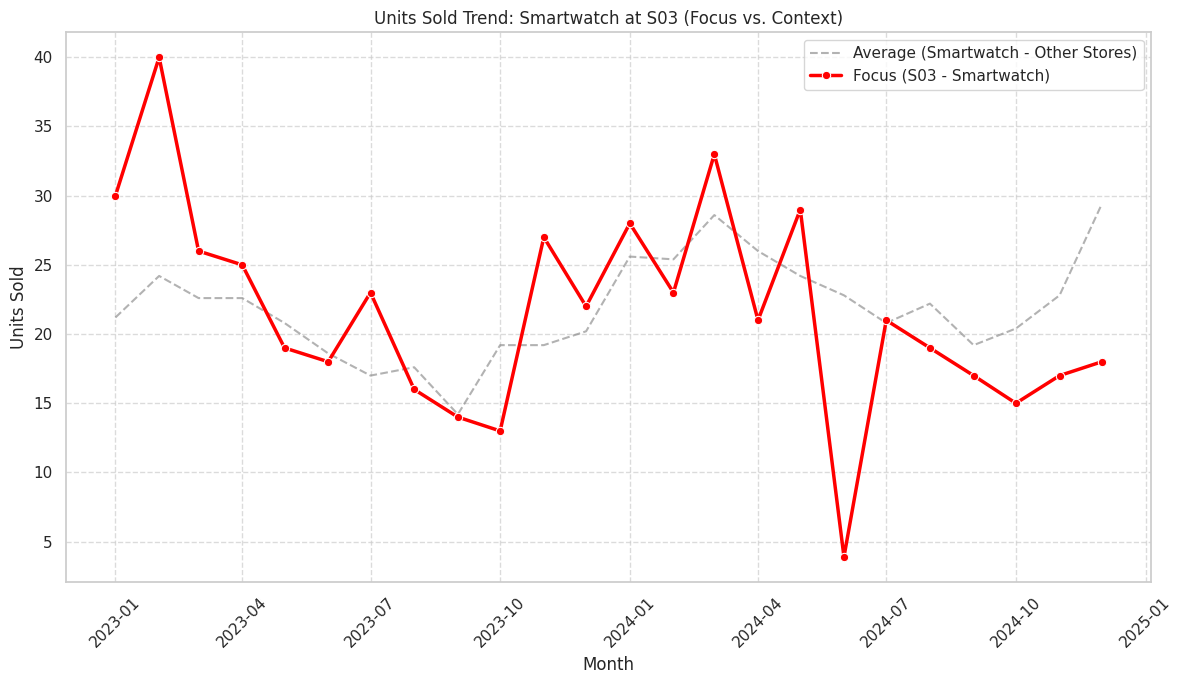

In [ ]:
# --- Part B: drill-down with context preserved ---
# TODO 1: build an overview plotly line chart of units_sold over month, one line per (store_id, product)
#         combination, with hover showing store_id + product (cheap-tier epistemic action)

# Create a combined identifier for each unique (store_id, product) pair
sales_df['store_product'] = sales_df['store_id'] + ' - ' + sales_df['product']

fig_overview = px.line(
    sales_df,
    x='month',
    y='units_sold',
    color='store_product', # Each unique store-product combination gets its own line
    title='Overview: Units Sold Trend by Store and Product',
    hover_data={'store_id': True, 'product': True, 'units_sold': True, 'month': '|%Y-%m-%d'}
)
fig_overview.update_layout(showlegend=False) # Hide legend as there are too many lines
fig_overview.show()

# TODO 2: using the (store_id, product) pair you identified as the top anomaly in Part A,
#         plot its monthly units_sold trend (focus) together with the average trend for that SAME
#         product across all other stores (context), on one shared chart

# Get the top anomaly
top_anomaly = anomaly_ranking.iloc[0]
anomaly_store_id = top_anomaly['store_id']
anomaly_product = top_anomaly['product']

# Data for the anomalous product and store (Focus)
anomaly_focus_df = sales_df[
    (sales_df['store_id'] == anomaly_store_id) &
    (sales_df['product'] == anomaly_product)
].sort_values('month')

# Data for the same product in all other stores (Context)
anomaly_context_df = sales_df[
    (sales_df['product'] == anomaly_product) &
    (sales_df['store_id'] != anomaly_store_id)
].groupby('month')['units_sold'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(
    x='month', y='units_sold', data=anomaly_context_df,
    color='gray', linestyle='--', alpha=0.6, label=f'Average ({anomaly_product} - Other Stores)'
)
sns.lineplot(
    x='month', y='units_sold', data=anomaly_focus_df,
    color='red', linewidth=2.5, marker='o', label=f'Focus ({anomaly_store_id} - {anomaly_product})'
)

plt.title(f'Units Sold Trend: {anomaly_product} at {anomaly_store_id} (Focus vs. Context)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_
I used the **hover** tier to first *spot* the anomaly in the overview line chart (cheap-tier epistemic action). To *investigate* it, I used a **click-to-open panel equivalent** (generating a new dedicated plot with focus and context). Using two different tiers was the right call, as it allowed for quick scanning (hover) to identify potential issues without commitment, and then a more dedicated view to analyze the specific anomaly, adhering to the drill-down cost hierarchy.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [ ]:
product_summary = sales_df.groupby('product').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum'),
    avg_rating=('avg_rating', 'mean')
).reset_index()

# Sort descending by revenue
product_summary = product_summary.sort_values(by='revenue', ascending=False)

# Style with .style.bar(...) per numeric column + .set_caption(...)
styled_product_summary_revenue = product_summary.style.bar(subset=['revenue'], color='lightcoral') \
                                              .bar(subset=['profit'], color='lightgreen') \
                                              .bar(subset=['avg_rating'], color='lightblue') \
                                              .set_caption('Product Performance Summary (Sorted by Revenue)')

display(styled_product_summary_revenue)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
1,Blender,7648773.000000,1860308.558382,4.039583
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


In [ ]:
# TODO: re-sort product_summary by profit descending and re-render the styled table

# Sort descending by profit
product_summary_profit_sorted = product_summary.sort_values(by='profit', ascending=False)

# Style with .style.bar(...) per numeric column + .set_caption(...)
styled_product_summary_profit = product_summary_profit_sorted.style.bar(subset=['revenue'], color='lightcoral') \
                                                    .bar(subset=['profit'], color='lightgreen') \
                                                    .bar(subset=['avg_rating'], color='lightblue') \
                                                    .set_caption('Product Performance Summary (Sorted by Profit)')

display(styled_product_summary_profit)

,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
1,Blender,7648773.000000,1860308.558382,4.039583
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


**Your observation (revenue-sorted vs profit-sorted top rows):**

_Your observation:_
When sorted by revenue, 'Smartwatch' and 'Air Fryer' are at the top, indicating high sales volume. However, when sorted by profit, 'Laptop Sleeve' and 'USB-C Hub' appear higher. This tells a manager that high-revenue products aren't always the most profitable, highlighting the importance of looking beyond just revenue to understand the true financial contribution of each product.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


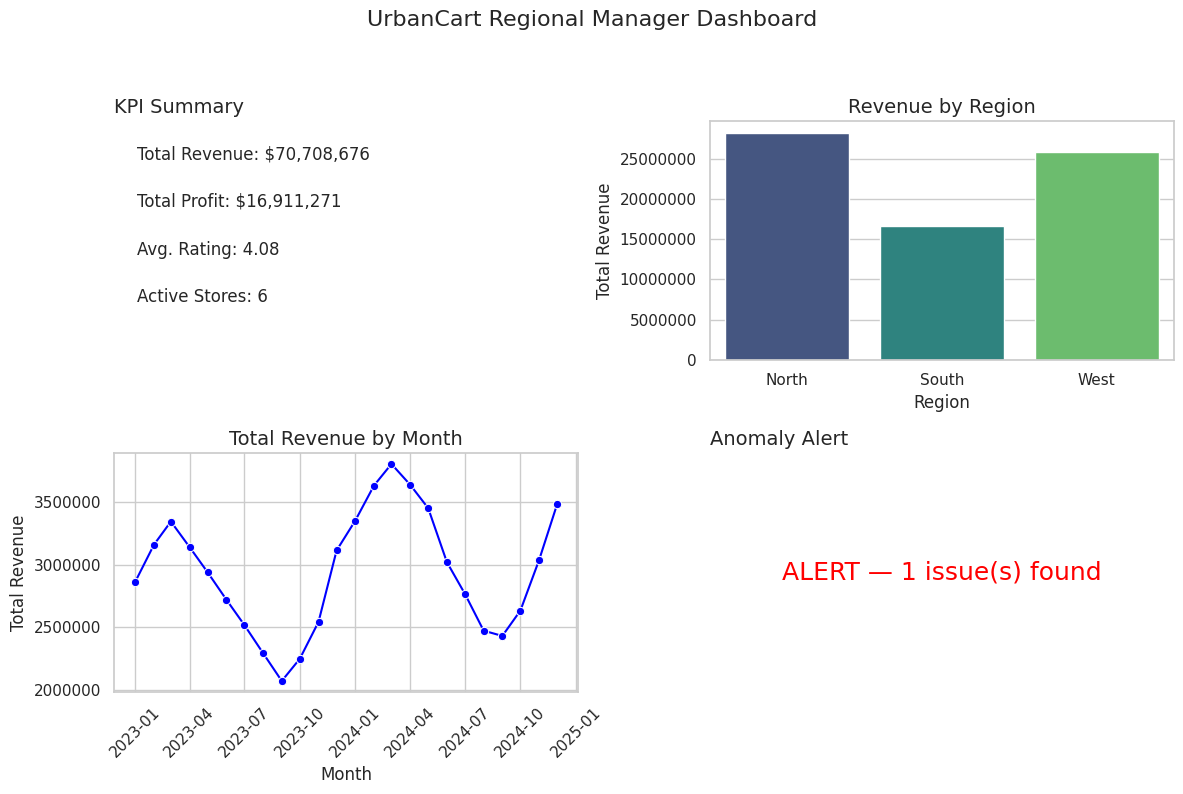

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
total_revenue = sales_df['revenue'].sum()
total_profit = sales_df['profit'].sum()
overall_avg_rating = sales_df['avg_rating'].mean()
num_active_stores = sales_df['store_id'].nunique()

axes[0, 0].axis("off")
axes[0, 0].text(0.05, 0.9, f"Total Revenue: ${total_revenue:,.0f}", fontsize=12, verticalalignment='top')
axes[0, 0].text(0.05, 0.7, f"Total Profit: ${total_profit:,.0f}", fontsize=12, verticalalignment='top')
axes[0, 0].text(0.05, 0.5, f"Avg. Rating: {overall_avg_rating:.2f}", fontsize=12, verticalalignment='top')
axes[0, 0].text(0.05, 0.3, f"Active Stores: {num_active_stores}", fontsize=12, verticalalignment='top')
axes[0, 0].set_title('KPI Summary', loc='left', fontsize=14)

# --- Panel 2: revenue by region (top-right) ---
revenue_by_region = sales_df.groupby('region')['revenue'].sum().reset_index()
sns.barplot(x='region', y='revenue', data=revenue_by_region, ax=axes[0, 1], palette='viridis', hue='region', legend=False)
axes[0, 1].set_title('Revenue by Region', fontsize=14)
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].ticklabel_format(style='plain', axis='y')

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
total_revenue_by_month = sales_df.groupby('month')['revenue'].sum().reset_index()
sns.lineplot(x='month', y='revenue', data=total_revenue_by_month, ax=axes[1, 0], marker='o', color='blue')
axes[1, 0].set_title('Total Revenue by Month', fontsize=14)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Revenue')
axes[1, 0].ticklabel_format(style='plain', axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
anomaly_check = sales_df.groupby(['store_id', 'product']).agg(
    min_units=('units_sold', 'min'),
    median_units=('units_sold', 'median')
).reset_index()
anomaly_check['min_to_median_ratio'] = anomaly_check['min_units'] / anomaly_check['median_units']

alert_condition = anomaly_check[anomaly_check['min_to_median_ratio'] < 0.25]
num_anomalies = len(alert_condition)

axes[1, 1].axis("off")
if num_anomalies > 0:
    axes[1, 1].text(0.5, 0.5, f"ALERT — {num_anomalies} issue(s) found", color='red', fontsize=18, ha='center', va='center')
else:
    axes[1, 1].text(0.5, 0.5, "OK", color='green', fontsize=18, ha='center', va='center')
axes[1, 1].set_title('Anomaly Alert', loc='left', fontsize=14)

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here:_
1. I believe the **Coordinated Views & Cross-View Brushing (Task 3)** would offer UrbanCart's managers the biggest time saving. It directly addresses Complaint #2 by allowing instantaneous comparison of store performance across multiple dimensions (overall, category, monthly trend) with a single selection, eliminating the need to flip through numerous static reports. This reduces working-memory load and provides immediate insights into how a selected store compares to others.

2. The **Focus + Context Drill-Down (Task 4)** was conceptually the hardest to implement well, particularly the *balance between focus and context*. The design trade-off was in ensuring the 'context' (average trend across other stores/products) was visible enough to provide comparison without overwhelming or distracting from the 'focus' (the anomalous store/product's trend). It's easy to make the context too dominant or too faint, either of which defeats the purpose of the comparison.

3. I would add a **Magic Lens** (from the lecture) to the **Single-Screen Monitoring Dashboard (Task 6)**. This would be useful in the 'Revenue by Region' panel. A manager could hover a magic lens over a specific region's bar in the bar chart, and the lens would reveal more detailed information *within that region*, such as the top 3 performing stores or categories, without needing a separate click or drill-down. This provides on-demand detail directly in the context of the overview, addressing Complaint #1 by allowing quick, localized investigation of regional performance drivers.